In [358]:
##ADD ALL IMPORTS HERE FOR ALL CELLS##
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt
from vega_datasets import data
import json
import urllib.request
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import SGDRegressor

In [288]:
PM25 = pd.read_csv("PM2.5.csv", skiprows=4, encoding="utf-8-sig")
PrimarySchoolGross = pd.read_csv('Primary_School_Enrollment_%Gross.csv', skiprows=4, encoding="utf-8-sig")
LifeExpectancy = pd.read_csv('Life_Expectancy.csv', skiprows=4, encoding="utf-8-sig")
GDPperCap = pd.read_csv('GDP_PCAP.csv', skiprows=4, encoding="utf-8-sig")
ForestArea = pd.read_csv('Forest_Area.csv', skiprows=4, encoding="utf-8-sig")
EnergyUse = pd.read_csv('EnergyUseData.csv', skiprows=4, encoding="utf-8-sig")
ExportofGnS = pd.read_csv('ExportofGoodandService.csv', skiprows=4, encoding="utf-8-sig")
RenewableElectricty = pd.read_csv('RenewableElectricyOutput.csv', skiprows=4, encoding="utf-8-sig")
WomenParliament = pd.read_csv('ProportionWomeninParliamnet.csv', skiprows=4, encoding="utf-8-sig")
PopulationDensity = pd.read_csv('PopulationDensity.csv', skiprows=4, encoding="utf-8-sig")
LivestockProduction = pd.read_csv('LivestockProductionIndex.csv', skiprows=4, encoding="utf-8-sig")

Datasets = {
    'PM25': PM25,
    'PrimarySchoolGross': PrimarySchoolGross,
    'LifeExpectancy': LifeExpectancy,
    'GDPperCap': GDPperCap,
    'ForestArea': ForestArea,
    'EnergyUse': EnergyUse,
    'ExportofGnS': ExportofGnS,
    'RenewableElectricty': RenewableElectricty,
    'WomenParliament': WomenParliament,
    'PopulationDensity': PopulationDensity,
    'LivestockProduction': LivestockProduction
}

new_df = {}
for name, df in Datasets.items():
    temp = df.melt(
        id_vars=['Country Name', 'Country Code', 'Indicator Name'],
        var_name='Year',
        value_name=name
    )
    temp = temp[temp['Year'].between('2000','2020')]
    temp['Year'] = temp['Year'].astype(int)
    new_df[name] = temp[['Country Name', 'Country Code', 'Year', name]]

fullset = new_df['PM25']
for name, df in new_df.items():
    if name != 'PM25':
        fullset = fullset.merge(df, on=['Country Name', 'Country Code', 'Year'], how='left')

sovereign_countries_iso3 = [
    'AFG','ALB','DZA','AND','AGO','ATG','ARG','ARM','AUS','AUT','AZE','BHS','BHR','BGD',
    'BRB','BLR','BEL','BLZ','BEN','BTN','BOL','BIH','BWA','BRA','BRN','BGR','BFA','BDI',
    'CPV','KHM','CMR','CAN','CAF','TCD','CHL','CHN','COL','COM','COD','COG','CRI','HRV',
    'CUB','CYP','CZE','DNK','DJI','DMA','DOM','ECU','EGY','SLV','GNQ','ERI','EST','SWZ',
    'ETH','FJI','FIN','FRA','GAB','GMB','GEO','DEU','GHA','GRC','GRD','GTM','GIN','GNB',
    'GUY','HTI','HND','HUN','ISL','IND','IDN','IRN','IRQ','IRL','ISR','ITA','JAM','JPN',
    'JOR','KAZ','KEN','KIR','KWT','KGZ','LAO','LVA','LBN','LSO','LBR','LBY','LIE','LTU',
    'LUX','MDG','MWI','MYS','MDV','MLI','MLT','MHL','MRT','MUS','MEX','FSM','MDA','MCO',
    'MNG','MNE','MAR','MOZ','MMR','NAM','NRU','NPL','NLD','NZL','NIC','NER','NGA','PRK',
    'MKD','NOR','OMN','PAK','PLW','PAN','PNG','PRY','PER','PHL','POL','PRT','QAT','ROU',
    'RUS','RWA','KNA','LCA','VCT','WSM','SMR','STP','SAU','SEN','SRB','SYC','SLE','SGP',
    'SVK','SVN','SLB','SOM','ZAF','KOR','SSD','ESP','LKA','SDN','SUR','SWE','CHE','SYR',
    'TJK','TZA','THA','TLS','TGO','TON','TTO','TUN','TUR','TKM','TUV','UGA','UKR','ARE',
    'GBR','USA','URY','UZB','VUT','VEN','VNM','YEM','ZMB','ZWE'
]

fullset = fullset[fullset['Country Code'].isin(sovereign_countries_iso3)]
fullset.to_csv('fullset.csv', index=False)
print(len(fullset['Country Name'].unique()))
fullset.to_csv('fullset.csv', index = False)

192


In [290]:
ullset = fullset.dropna(subset=['PM25']).sort_values(['Country Code','Year'])

feature_cols = ['PrimarySchoolGross','GDPperCap','ForestArea','EnergyUse',
                'ExportofGnS','RenewableElectricty','WomenParliament',
                'PopulationDensity','LivestockProduction','LifeExpectancy']

fullset[feature_cols] = fullset[feature_cols].apply(pd.to_numeric, errors='coerce')

fullset[feature_cols] = (
    fullset.groupby('Country Code')[feature_cols]
           .transform(lambda x: x.interpolate().ffill().bfill())
)

fullset['PM25'] = pd.to_numeric(fullset['PM25'], errors='coerce')
fullset['PM25'] = (
    fullset.groupby('Country Code')['PM25']
           .transform(lambda x: x.interpolate().ffill().bfill())
)

fullset['PM25'] = fullset['PM25'].fillna(fullset['PM25'].median())

fullset = fullset.dropna(subset=feature_cols)

fullset.isna().sum()

Country Name           0
Country Code           0
Year                   0
PM25                   0
PrimarySchoolGross     0
LifeExpectancy         0
GDPperCap              0
ForestArea             0
EnergyUse              0
ExportofGnS            0
RenewableElectricty    0
WomenParliament        0
PopulationDensity      0
LivestockProduction    0
dtype: int64

In [291]:
env_vars = ['ForestArea','RenewableElectricty','EnergyUse']
econ_vars = ['GDPperCap','ExportofGnS','LivestockProduction']
soc_vars = ['LifeExpectancy','PrimarySchoolGross','WomenParliament','PopulationDensity']

scaler = StandardScaler()

env_index = PCA(n_components=1).fit_transform(scaler.fit_transform(fullset[env_vars]))
econ_index = PCA(n_components=1).fit_transform(scaler.fit_transform(fullset[econ_vars]))
soc_index = PCA(n_components=1).fit_transform(scaler.fit_transform(fullset[soc_vars]))

fullset['Env_Index'] = env_index
fullset['Econ_Index'] = econ_index
fullset['Soc_Index'] = soc_index

fullset['USI'] = (
    fullset['Env_Index'] +
    fullset['Econ_Index'] +
    fullset['Soc_Index']
) / 3

CountryTable = ['United States','China','India','United Kingdom','Germany']

USItable = fullset[(fullset['Year'] == 2015) &
                  (fullset['Country Name'].isin(CountryTable))]

USItable[['Country Name','Year','Env_Index','Econ_Index','Soc_Index','USI']]

,Country Name,Year,Env_Index,Econ_Index,Soc_Index,USI
4030,China,2015,-0.421575,-0.576706,0.615004,-0.127759
4045,Germany,2015,-0.333575,1.229724,1.665536,0.853895
4071,United Kingdom,2015,-0.739794,0.984831,1.426263,0.557100
4099,India,2015,-0.271623,-0.861883,0.070094,-0.354471
4241,United States,2015,-1.161906,0.999550,0.575899,0.137848


**PART B**

In [292]:
alt.renderers.enable('default')

Datasets = {
    'PM25': PM25,
    'PrimarySchoolGross': PrimarySchoolGross,
    'LifeExpectancy': LifeExpectancy,
    'GDPperCap': GDPperCap,
    'ForestArea': ForestArea,
    'EnergyUse': EnergyUse,
    'ExportofGnS': ExportofGnS,
    'RenewableElectricty': RenewableElectricty,
    'WomenParliament': WomenParliament,
    'PopulationDensity': PopulationDensity,
    'LivestockProduction': LivestockProduction
}

new_df = {}
for name, df in Datasets.items():
    temp = df.melt(
        id_vars=['Country Name', 'Country Code', 'Indicator Name'],
        var_name='Year',
        value_name=name
    )
    temp = temp[temp['Year'].between('2000','2020')]
    temp['Year'] = temp['Year'].astype(int)
    new_df[name] = temp[['Country Name', 'Country Code', 'Year', name]]

fullset_all_countries = new_df['PM25']
for name, df in new_df.items():
    if name != 'PM25':
        fullset_all_countries = fullset_all_countries.merge(
            df, on=['Country Name', 'Country Code', 'Year'], how='left'
        )

fullset_all_countries['PM25'] = pd.to_numeric(fullset_all_countries['PM25'], errors='coerce')

mean_pm25 = (
    fullset_all_countries.groupby(['Country Name','Country Code'])['PM25']
    .mean()
    .reset_index()
)

iso_df = pd.read_csv('country-codes.csv', usecols=['ISO3166-1-Alpha-3', 'ISO3166-1-numeric'])
iso_df = iso_df.rename(columns={'ISO3166-1-Alpha-3': 'Country Code', 'ISO3166-1-numeric': 'iso_numeric'})
mean_pm25 = mean_pm25.merge(iso_df, on='Country Code', how='left')
mean_pm25['iso_numeric'] = mean_pm25['iso_numeric'].astype(float)

world_url = data.world_110m.url
with urllib.request.urlopen(world_url) as response:
    world_json = json.load(response)

all_country_ids = [feature['id'] for feature in world_json['objects']['countries']['geometries']]

all_countries = pd.DataFrame({'iso_numeric': all_country_ids})
all_countries = all_countries.merge(
    mean_pm25[['iso_numeric','PM25','Country Name']],
    on='iso_numeric',
    how='left'
)

world = alt.topo_feature(data.world_110m.url, 'countries')

chart = alt.Chart(world).mark_geoshape().encode(
    color=alt.condition(
        'datum.PM25 != null',
        alt.Color('PM25:Q', scale=alt.Scale(scheme='yellowgreenblue'), title='Mean PM2.5 (2000-2020)'),
        alt.value('lightgray')  # fill missing countries
    ),
    tooltip=[
        alt.Tooltip('Country Name:N', title='Country'),
        alt.Tooltip('PM25:Q', title='Mean PM2.5', format=".2f")
    ]
).transform_lookup(
    lookup='id',
    from_=alt.LookupData(all_countries, 'iso_numeric', ['PM25','Country Name'])
).project('equirectangular').properties(
    width=900,
    height=450,
    title='Global Mean PM2.5 Levels (2000-2020)'
).interactive()

chart

alt.Chart(...)

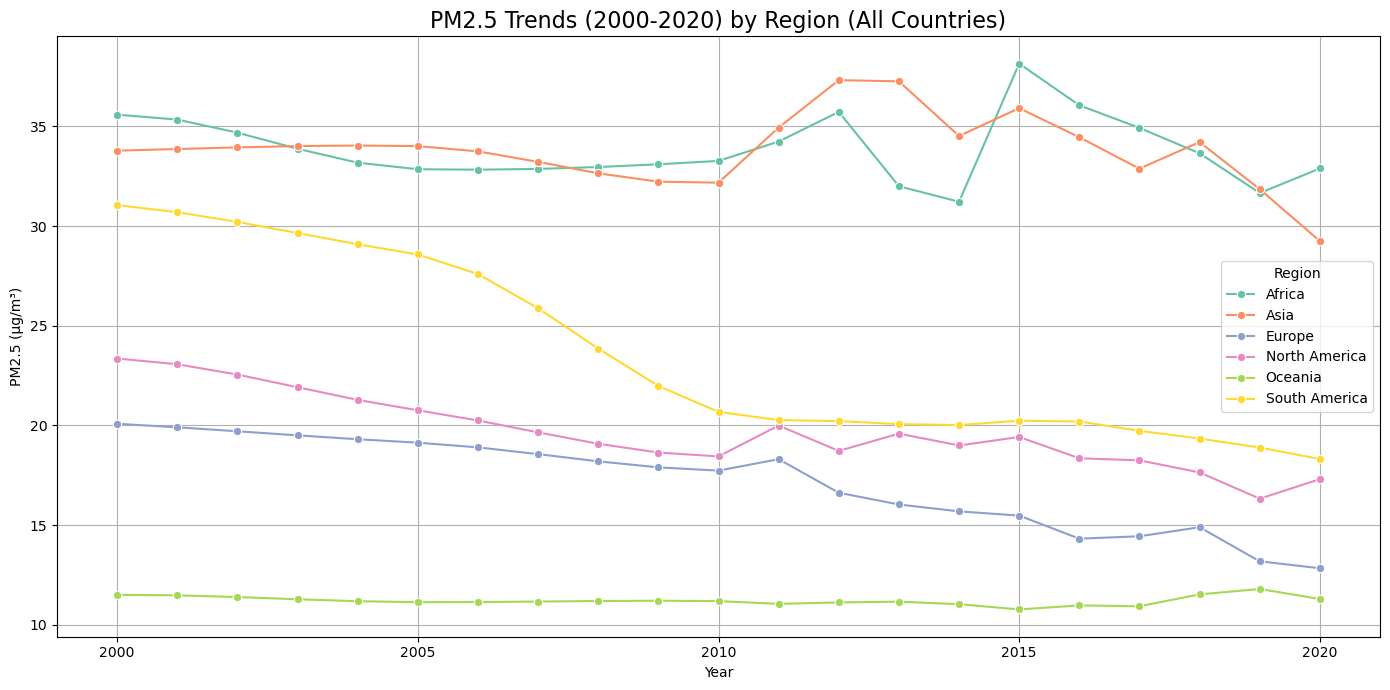

In [293]:
region_mapping_codes = {
    # Africa
    "DZA": "Africa", "AGO": "Africa", "BEN": "Africa", "BWA": "Africa", "BFA": "Africa",
    "BDI": "Africa", "CMR": "Africa", "CPV": "Africa", "CAF": "Africa", "TCD": "Africa",
    "COM": "Africa", "COD": "Africa", "COG": "Africa", "DJI": "Africa", "GNQ": "Africa",
    "ERI": "Africa", "SWZ": "Africa", "ETH": "Africa", "GAB": "Africa", "GMB": "Africa",
    "GHA": "Africa", "GIN": "Africa", "GNB": "Africa", "KEN": "Africa", "LSO": "Africa",
    "LBR": "Africa", "LBY": "Africa", "MDG": "Africa", "MWI": "Africa", "MRT": "Africa",
    "MUS": "Africa", "MAR": "Africa", "MOZ": "Africa", "NAM": "Africa", "NER": "Africa",
    "NGA": "Africa", "RWA": "Africa", "STP": "Africa", "SEN": "Africa", "SYC": "Africa",
    "SLE": "Africa", "SOM": "Africa", "ZAF": "Africa", "SSD": "Africa", "SDN": "Africa",
    "TZA": "Africa", "TGO": "Africa", "TUN": "Africa", "UGA": "Africa", "ZMB": "Africa",
    "ZWE": "Africa",

    # Asia
    "AFG": "Asia", "ARM": "Asia", "AZE": "Asia", "BHR": "Asia", "BGD": "Asia", "BTN": "Asia",
    "BRN": "Asia", "KHM": "Asia", "CHN": "Asia", "CYP": "Asia", "GEO": "Asia", "IND": "Asia",
    "IDN": "Asia", "IRN": "Asia", "IRQ": "Asia", "ISR": "Asia", "JPN": "Asia", "JOR": "Asia",
    "KAZ": "Asia", "PRK": "Asia", "KOR": "Asia", "KWT": "Asia", "KGZ": "Asia", "LAO": "Asia",
    "LBN": "Asia", "MYS": "Asia", "MDV": "Asia", "MNG": "Asia", "MMR": "Asia", "NPL": "Asia",
    "OMN": "Asia", "PAK": "Asia", "PHL": "Asia", "QAT": "Asia", "SAU": "Asia", "SGP": "Asia",
    "LKA": "Asia", "SYR": "Asia", "TJK": "Asia", "TLS": "Asia", "TKM": "Asia", "ARE": "Asia",
    "UZB": "Asia", "VNM": "Asia", "YEM": "Asia",

    # Europe
    "ALB": "Europe", "AND": "Europe", "AUT": "Europe", "BLR": "Europe", "BEL": "Europe",
    "BIH": "Europe", "BGR": "Europe", "HRV": "Europe", "CZE": "Europe", "DNK": "Europe",
    "EST": "Europe", "FIN": "Europe", "FRA": "Europe", "DEU": "Europe", "GRC": "Europe",
    "HUN": "Europe", "ISL": "Europe", "IRL": "Europe", "ITA": "Europe", "LVA": "Europe",
    "LIE": "Europe", "LTU": "Europe", "LUX": "Europe", "MLT": "Europe", "MCO": "Europe",
    "MNE": "Europe", "NLD": "Europe", "MKD": "Europe", "NOR": "Europe", "POL": "Europe",
    "PRT": "Europe", "ROU": "Europe", "RUS": "Europe", "SMR": "Europe", "SRB": "Europe",
    "SVK": "Europe", "SVN": "Europe", "ESP": "Europe", "SWE": "Europe", "CHE": "Europe",
    "TUR": "Europe", "UKR": "Europe", "GBR": "Europe",

    # North America
    "CAN": "North America", "USA": "North America", "MEX": "North America", "BLZ": "North America",
    "CRI": "North America", "SLV": "North America", "GTM": "North America", "HND": "North America",
    "NIC": "North America", "PAN": "North America", "BHS": "North America", "BRB": "North America",
    "CUB": "North America", "DMA": "North America", "DOM": "North America", "GRD": "North America",
    "JAM": "North America", "KNA": "North America", "LCA": "North America", "VCT": "North America",
    "TTO": "North America", "ATG": "North America",

    # South America
    "ARG": "South America", "BOL": "South America", "BRA": "South America", "CHL": "South America",
    "COL": "South America", "ECU": "South America", "GUY": "South America", "PRY": "South America",
    "PER": "South America", "SUR": "South America", "URY": "South America", "VEN": "South America",

    # Oceania
    "AUS": "Oceania", "FJI": "Oceania", "KIR": "Oceania", "MHL": "Oceania", "FSM": "Oceania",
    "NRU": "Oceania", "NZL": "Oceania", "PLW": "Oceania", "PNG": "Oceania", "SLB": "Oceania",
    "TON": "Oceania", "TUV": "Oceania", "VUT": "Oceania", "WSM": "Oceania",
}

fullset['Region'] = fullset['Country Code'].map(region_mapping_codes)
fullset_sorted = fullset.sort_values(['Region', 'Country Name', 'Year'])
pm_region_trend = fullset_sorted.groupby(['Region','Year'])['PM25'].mean().reset_index()

plt.figure(figsize=(14,7))
sns.lineplot(
    data=pm_region_trend,
    x='Year',
    y='PM25',
    hue='Region',
    marker='o',
    palette='Set2'
)
plt.title('PM2.5 Trends (2000-2020) by Region (All Countries)', fontsize=16)
plt.xlabel('Year')
plt.ylabel('PM2.5 (µg/m³)')

years = list(range(pm_region_trend['Year'].min(), pm_region_trend['Year'].max()+1, 5))
plt.xticks(years)

plt.grid(True)
plt.legend(title='Region')
plt.tight_layout()
plt.show()

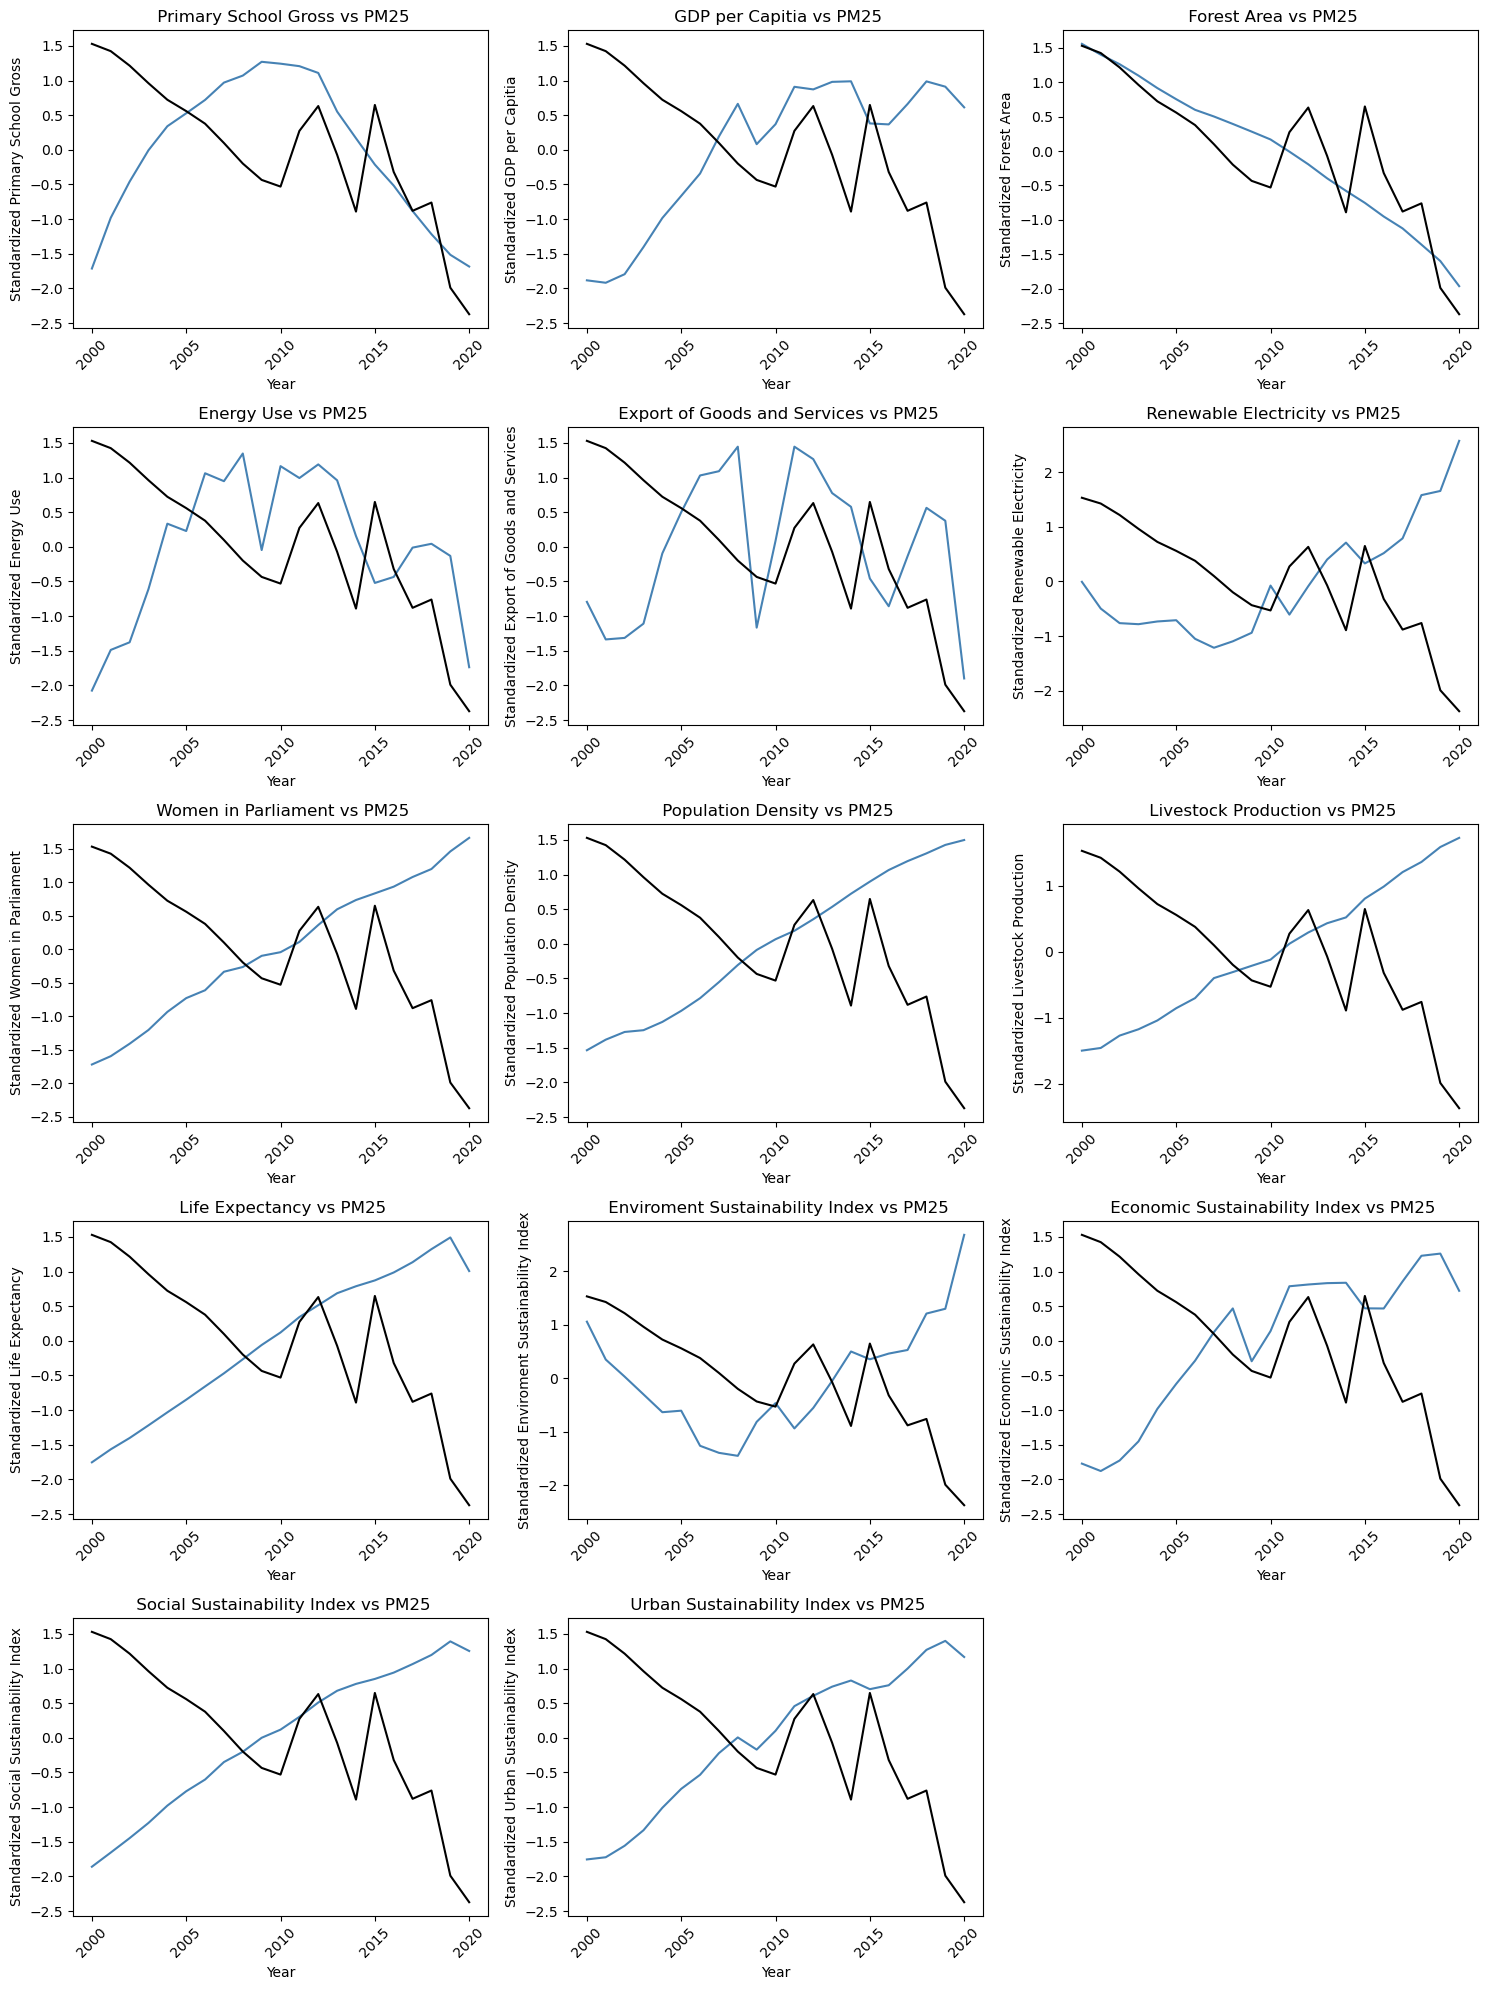

In [294]:
scaler = StandardScaler()
titles = [
    "Primary School Gross",
    "GDP per Capitia",
    "Forest Area",
    "Energy Use",
    "Export of Goods and Services",
    "Renewable Electricity",
    "Women in Parliament",
    "Population Density",
    "Livestock Production",
    'Life Expectancy',
    "Enviroment Sustainability Index",
    'Economic Sustainability Index',
    "Social Sustainability Index",
    'Urban Sustainability Index'
]

assert len(titles) == len(num_cols), "titles and num_cols must be the same length"

n = len(num_cols)
cols = 3
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(15, 4*rows), sharex=True)
axes = axes.flatten()

years_all = np.sort(fullset['Year'].dropna().unique())
tick_years = years_all[::5]

for idx, col in enumerate(num_cols):

    df = fullset.groupby('Year')[[col, 'PM25']].mean()

    df_scaled = pd.DataFrame(
        scaler.fit_transform(df),
        index=df.index,
        columns=df.columns
    )

   
    axes[idx].plot(df_scaled.index, df_scaled[col], color='steelblue')
    axes[idx].plot(df_scaled.index, df_scaled['PM25'], color='black')

   
    axes[idx].set_title(f" {titles[idx]} vs PM25")

    axes[idx].set_xlabel("Year")
    axes[idx].set_ylabel(f"Standardized {titles[idx]}")

    axes[idx].set_xticks(tick_years)
    axes[idx].tick_params(axis='x', rotation=45, labelbottom=True)

# remove empty plots
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

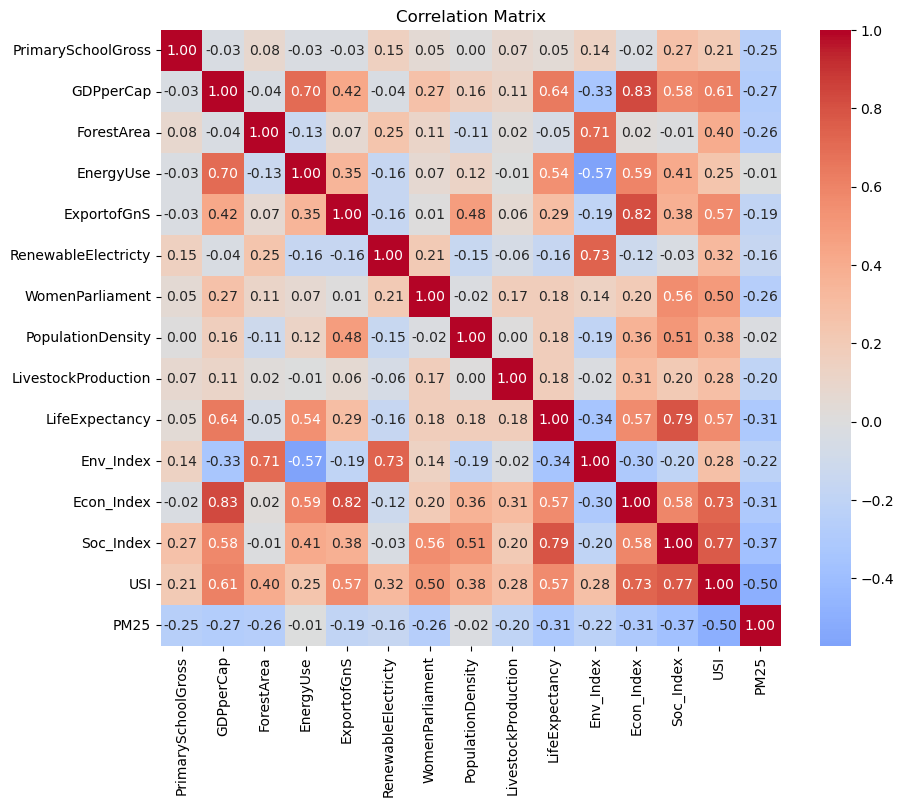

In [295]:
num_cols = feature_cols + ['Env_Index', 'Econ_Index', 'Soc_Index', 'USI']
corr_matrix = fullset[num_cols + ['PM25']].corr()
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

**PART C**

In [296]:
predictors = ['ForestArea','RenewableElectricty','EnergyUse','GDPperCap',
              'ExportofGnS','LivestockProduction','LifeExpectancy',
              'PrimarySchoolGross','WomenParliament','PopulationDensity']

target = "PM25"
fullset = fullset.copy()

train_df = fullset[fullset["Year"] <= 2015].copy()
test_df  = fullset[fullset["Year"] >  2015].copy()

X_train = train_df[predictors].values
y_train = train_df[target].values

X_test  = test_df[predictors].values
y_test  = test_df[target].values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [365]:
RandomForest = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [400, 600, 800, 1000],
    "max_depth": [5, 10, 15, 20]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid_rf = GridSearchCV(
    estimator=RandomForest,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error", 
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_rf.fit(X_train_scaled, y_train)


print("Best Params:", grid_rf.best_params_)

best_rf = grid_rf.best_estimator_
test_pred_rf = best_rf.predict(X_test_scaled)
test_rmse_rf = np.sqrt(mean_squared_error(y_test, test_pred_rf))
r2_rf = r2_score(y_test, test_pred_rf)
print("Test RMSE:", test_rmse_rf)
print("RF R2:", r2_rf)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Params: {'max_depth': 20, 'n_estimators': 800}
Test RMSE: 6.566487195338889
RF R2: 0.8385937106585662


In [369]:
GradientDesc = SGDRegressor(
    loss="squared_error",
    learning_rate="constant",
    penalty="l2", 
    random_state=42
)

param_grid = {
    "eta0": [1e-4, 1e-3, 1e-2, 1e-1],
    "max_iter": [1000, 3000, 5000, 10000]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid_gd = GridSearchCV(
    estimator=GradientDesc,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_gd.fit(X_train_scaled, y_train)

print("Best Params:", grid_gd.best_params_)

best_gd = grid_gd.best_estimator_
test_pred_gd = best_gd.predict(X_test_scaled)
test_rmse_gd = np.sqrt(mean_squared_error(y_test, test_pred_gd))
r2_gd = r2_score(y_test, test_pred_gd)
print("Test RMSE:", test_rmse_gd)
print("GD R2:", r2_gd)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Params: {'eta0': 0.0001, 'max_iter': 1000}
Test RMSE: 14.092954820815136
GD R2: 0.256538695685237


In [381]:
input_dim = X_train_scaled.shape[1]

Xtr = torch.tensor(X_train_scaled, dtype=torch.float32)
Xte = torch.tensor(X_test_scaled, dtype=torch.float32)

ytr = torch.tensor(np.asarray(y_train, dtype=np.float32)).view(-1,1)
yte = torch.tensor(np.asarray(y_test, dtype=np.float32)).view(-1,1)

deep_model = nn.Sequential(
    nn.Linear(input_dim,128),
    nn.ReLU(),
    nn.Linear(128,64),
    nn.ReLU(),
    nn.Linear(64,32),
    nn.ReLU(),
    nn.Linear(32,1)
)

loss_fun = nn.MSELoss()
optimizer = torch.optim.Adam(deep_model.parameters(), lr=0.003)

epochs = 300
for epoch in range(epochs):
    preds = deep_model(Xtr)
    loss = loss_fun(preds, ytr)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

train_pred_dnn = deep_model(Xtr).detach().numpy().ravel()
test_pred_dnn  = deep_model(Xte).detach().numpy().ravel()

train_rmse_dnn = np.sqrt(mean_squared_error(y_train, train_pred_dnn))
test_rmse_dnn  = np.sqrt(mean_squared_error(y_test, test_pred_dnn))
r2_dnn = r2_score(y_test, test_pred_dnn)

print("Deep Train RMSE:", train_rmse_dnn)
print("Deep Test RMSE:", test_rmse_dnn)
print("DNN R2:", r2_dnn)

Deep Train RMSE: 9.552078765727657
Deep Test RMSE: 11.163549247950714
DNN R2: 0.5334922798997004


In [382]:
wide_model = nn.Sequential(
    nn.Linear(input_dim,1)
)

loss_fun = nn.MSELoss()
optimizer = torch.optim.Adam(wide_model.parameters(), lr=0.001)

epochs = 5000
for epoch in range(epochs):
    preds = wide_model(Xtr)
    loss = loss_fun(preds, ytr)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

wide_train_pred = wide_model(Xtr).detach().numpy().ravel()
wide_test_pred  = wide_model(Xte).detach().numpy().ravel()

wide_train_rmse = np.sqrt(mean_squared_error(y_train, wide_train_pred))
wide_test_rmse  = np.sqrt(mean_squared_error(y_test, wide_test_pred))
r2_wide = r2_score(y_test, wide_test_pred)

print("Wide Train RMSE:", wide_train_rmse)
print("Wide Test RMSE:", wide_test_rmse)
print("Wide R2:", r2_wide)

Wide Train RMSE: 26.084845767982888
Wide Test RMSE: 28.558050899735083
Wide R2: -2.0528915482048418


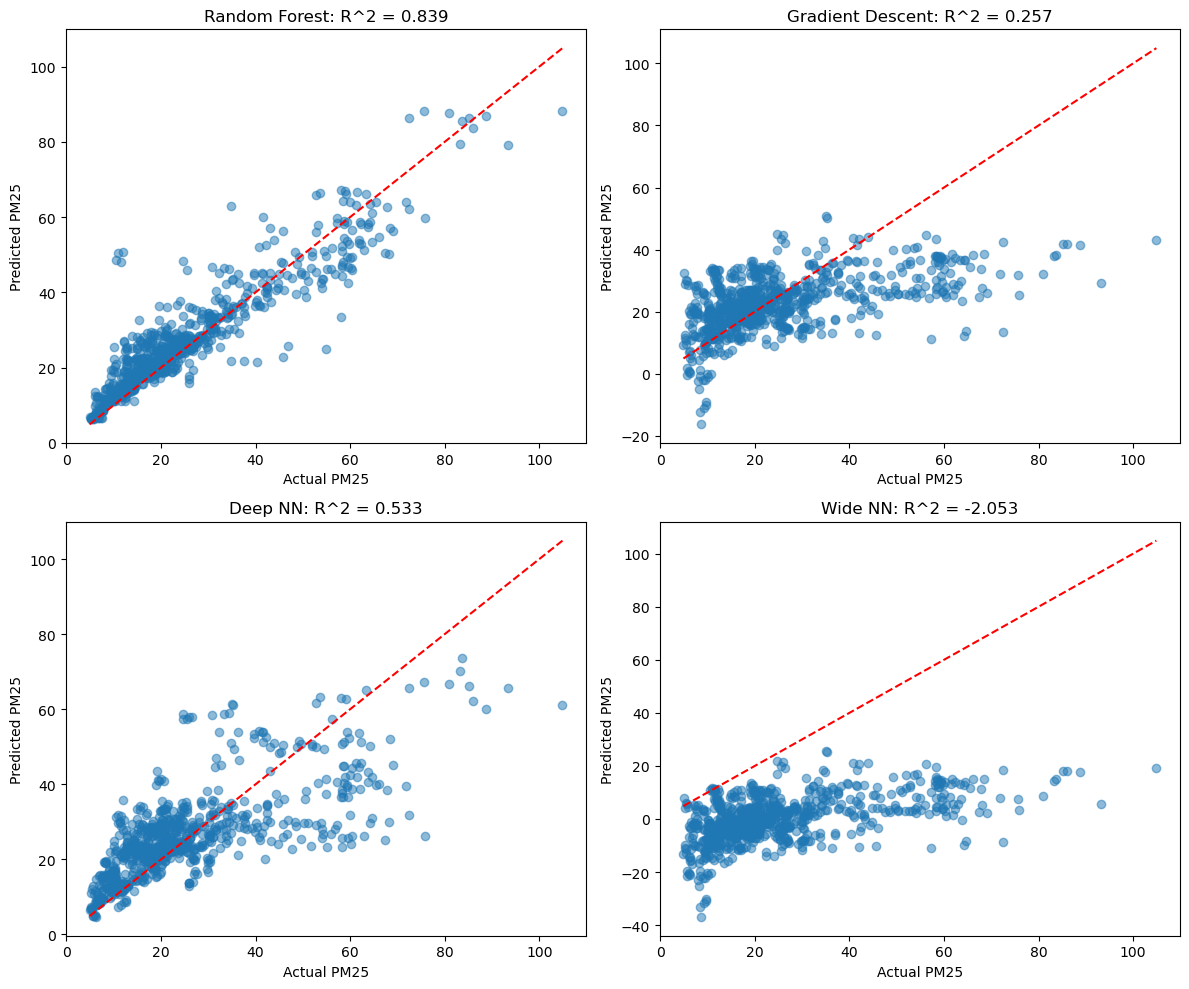

In [383]:
fig, axs = plt.subplots(2,2, figsize=(12,10))

# Random Forest
axs[0,0].scatter(y_test, test_pred_rf, alpha=0.5)
axs[0,0].plot([y_test.min(), y_test.max()],
              [y_test.min(), y_test.max()], 'r--')
axs[0,0].set_title(f"Random Forest: R^2 = {round(r2_rf,3)}")
axs[0,0].set_xlabel("Actual PM25")
axs[0,0].set_ylabel("Predicted PM25")

# Gradient Descent
axs[0,1].scatter(y_test, test_pred_gd, alpha=0.5)
axs[0,1].plot([y_test.min(), y_test.max()],
              [y_test.min(), y_test.max()], 'r--')
axs[0,1].set_title(f"Gradient Descent: R^2 = {round(r2_gd,3)}")
axs[0,1].set_xlabel("Actual PM25")
axs[0,1].set_ylabel("Predicted PM25")

# Deep Neural Network
axs[1,0].scatter(y_test, test_pred_dnn, alpha=0.5)
axs[1,0].plot([y_test.min(), y_test.max()],
              [y_test.min(), y_test.max()], 'r--')
axs[1,0].set_title(f"Deep NN: R^2 = {round(r2_dnn,3)}")
axs[1,0].set_xlabel("Actual PM25")
axs[1,0].set_ylabel("Predicted PM25")

# Wide Neural Network
axs[1,1].scatter(y_test, wide_test_pred, alpha=0.5)
axs[1,1].plot([y_test.min(), y_test.max()],
              [y_test.min(), y_test.max()], 'r--')
axs[1,1].set_title(f"Wide NN: R^2 = {round(r2_wide,3)}")
axs[1,1].set_xlabel("Actual PM25")
axs[1,1].set_ylabel("Predicted PM25")

plt.tight_layout()
plt.show()